**Orbital Rendezvous Scenario**

This notebook shows a LEO to GEO rendezvous scenario going through the various stages of:
* Insertion to LEO
* LEO to GEO transfer
* GEO plane change (delta i is 28 degrees, assuming cheap spacex launch from florida to satellite over europe)
* Phasing
* Far-range approach (100 - 10 km)
* Medium-range approach (10 - 1km)
* Close-range approach (1km - 100m)
* Straight-line approach and docking (100 - 1m)

In [17]:
# library imports
from math import pi, sqrt
import numpy as np

# Constants
mu_earth = 398_600 # km^3/s^2
r_earth  = 6371          # km

# LEO starting orbit characteristics
alt_leo = 400 # km
i_leo   = 28  # degrees (assume cheap SpaceX launch from Cape Canaveral)

# GEO starting orbit characteristics (target is focused on Munich, approx 11.4 deg E)
alt_geo = 35786 # km
i_geo   = 0     # degrees

def v_vis_viva(r_t: float,
               a: float,
               mu_val: float) -> float:
    """
    Returns velocity magnitude from standard vis-viva eqaution for elliptical orbits

    """
    v = sqrt(mu_val * ( (2/r_t) - (1/a) ))

    return v

In [18]:
# LEO to GEO transfer orbit characteristics
a_transfer = (alt_leo + alt_geo + r_earth*2)/2 # km
t_transfer = pi * sqrt(a_transfer**3 / mu_earth)

V_LEO = sqrt(mu_earth / (r_earth + alt_leo))
V_Hp = v_vis_viva(r_earth + alt_leo, a_transfer, mu_earth)
V_GEO = sqrt(mu_earth / (r_earth + alt_geo))
V_Ap = v_vis_viva(2*a_transfer - (r_earth + alt_leo), a_transfer, mu_earth)

dV1 = V_Hp - V_LEO
dV2 = V_GEO - V_Ap
dV_leo_geo_transfer = dV1 + dV2

print(f"{V_LEO}\n {V_Hp}\n {V_GEO}\n {V_Ap}\n")
print(f"Delta-V 1 for LEO to GEO transfer maneuver: {dV1:.2f} km/s")
print(f"Delta-V 2 for LEO to GEO transfer maneuver: {dV2:.2f} km/s")
print(f"Total Delta-V for LEO to GEO transfer maneuver that is IN PLANE: {dV_leo_geo_transfer:.2f} km/s")

print(f"Total transfer time from LEO to GEO: {t_transfer/3600:.2f} hours")

7.6725943963136825
 10.071945222622249
 3.0749198374180353
 1.617694359237499

Delta-V 1 for LEO to GEO transfer maneuver: 2.40 km/s
Delta-V 2 for LEO to GEO transfer maneuver: 1.46 km/s
Total Delta-V for LEO to GEO transfer maneuver that is IN PLANE: 3.86 km/s
Total transfer time from LEO to GEO: 5.29 hours


In [19]:
# GEO plane change delta-v

delta_i = abs(i_leo - i_geo) * (pi/180) # radians
V_GEO = sqrt(mu_earth / (r_earth + alt_geo))

dv_geo_i_change = 2 * V_GEO * np.sin(delta_i / 2)
print(f"Total Delta-V for GEO plane change of {delta_i*180/pi} deg: {dv_geo_i_change:.2f} km/s")

Total Delta-V for GEO plane change of 28.0 deg: 1.49 km/s


In [20]:
# Running Delta-V total:

print(f"Total Delta-V for LEO to GEO transfer plus GEO plane change: {dV_leo_geo_transfer + dv_geo_i_change:.2f} km/s")

Total Delta-V for LEO to GEO transfer plus GEO plane change: 5.34 km/s


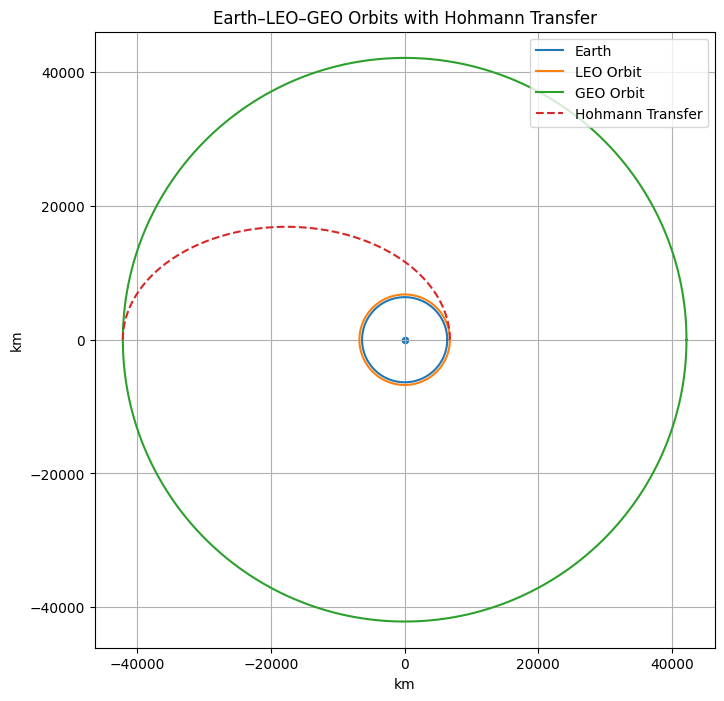

In [21]:
# Plotting the orbits

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Constants (km)
# -----------------------------
R_EARTH = 6371            # Earth radius
R_LEO = R_EARTH + 400     # Typical LEO (~400 km altitude)
R_GEO = 42164             # GEO orbital radius

# -----------------------------
# Angles
# -----------------------------
theta = np.linspace(0, 2*np.pi, 500)
theta_half = np.linspace(0, np.pi, 500)

# -----------------------------
# Circles
# -----------------------------
earth_x = R_EARTH * np.cos(theta)
earth_y = R_EARTH * np.sin(theta)

leo_x = R_LEO * np.cos(theta)
leo_y = R_LEO * np.sin(theta)

geo_x = R_GEO * np.cos(theta)
geo_y = R_GEO * np.sin(theta)

# -----------------------------
# Hohmann Transfer Ellipse
# -----------------------------
a = (R_LEO + R_GEO) / 2                  # Semi-major axis
e = (R_GEO - R_LEO) / (R_GEO + R_LEO)    # Eccentricity
r = a * (1 - e**2) / (1 + e * np.cos(theta_half))

hohmann_x = r * np.cos(theta_half)
hohmann_y = r * np.sin(theta_half)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 8))

plt.plot(earth_x, earth_y, label="Earth")
plt.plot(leo_x, leo_y, label="LEO Orbit")
plt.plot(geo_x, geo_y, label="GEO Orbit")
plt.plot(hohmann_x, hohmann_y, linestyle="--", label="Hohmann Transfer")

plt.scatter(0, 0, s=20)  # Earth center

plt.axis("equal")
plt.xlabel("km")
plt.ylabel("km")
plt.title("Earth–LEO–GEO Orbits with Hohmann Transfer")
plt.legend()
plt.grid(True)

plt.show()


This is a mahooosive amount of dV using impulsize thrusting methods

Much more common to use EP methods and set up a constrained optimization problem with boundary conditions; think of plane change and transfer being coupled states. Set time to free variable as well as arrive phase, then good to go. 

Constraints:
* No thrusting in eclipse
* Can't go through the earth / lower than LEO altitude

**Next steps - set this mission scenario up in GMAT and then reverse engineer through own calculations**